In [1]:
import os

# Set the environment variable to avoid printing the error message
os.environ["EQX_ON_ERROR"] = "nan"

import numpy as np
import jax
import healpy as hp

import matplotlib.pyplot as plt

import megatop
import megabuster


jax.config.update("jax_enable_x64", True)


In [2]:
# Preparing paths

path_scratch = '/pscratch/sd/m/mag/fast_MSS2_obsmat/'
path_precomputations = path_scratch

# Generating input CMB and input mask

In [3]:
from fgbuster import get_observation, get_instrument

nside = 128 
npix = 12*nside**2
nstokes = 2


frequencies = np.array([27, 39, 93, 145, 225, 280])

n_freq = len(frequencies)

# Get simulated map
instrument = get_instrument('SO_SAT')


np.random.seed(42)
input_freq_maps = get_observation(instrument, 'c1d0s0', nside=nside, noise=False)

np.random.seed(42)
input_cmb = get_observation(instrument, 'c1', nside=nside, noise=False)


0.134796142578125

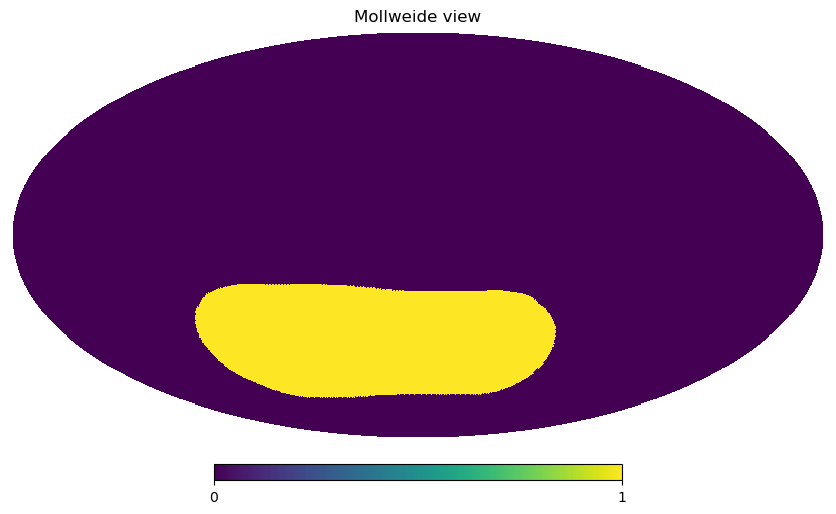

In [19]:
def make_mask(nhits_path, zero_threshold, nside):
    nhits_map = hp.read_map(nhits_path)
    nhits_smoothed = hp.smoothing(
        hp.ud_grade(nhits_map, nside, power=-2, dtype=np.float64),
        fwhm=np.pi/180)
    nhits_smoothed[nhits_smoothed < 0] = 0
    nhits_smoothed /= np.amax(nhits_smoothed)
    binary_mask = np.zeros_like(nhits_smoothed)
    binary_mask[nhits_smoothed > zero_threshold] = 1
    fsky = np.sum(binary_mask) / len(binary_mask)

    return binary_mask, fsky

nside_out = 128  # Output nside for the mask

# path_MSS = '/lustre/fswork/projects/rech/nih/commun/megatop/MSS2/ivar/'
path_MSS = '/global/cfs/cdirs/sobs/sims/mss-0002/RC1.r01/'
zero_threshold = 0.1
path_nhits = path_MSS+f"sobs_RC1.r01_SAT4_mission_f030_4way_coadd_sky_ivar_healpix.fits"
mask_B, fsky = make_mask(path_nhits, zero_threshold, nside=nside_out)

theta, phi = hp.pix2ang(nside=nside_out, ipix=np.arange(mask_B.size), lonlat=True)

mask_south = np.zeros_like(mask_B)

mask_south[theta < 115] = 1
mask_south[theta > 280] = 1
mask_south[phi < -35] = 1
mask_south[phi > -15] = 0

mask_B_ring = mask_B * mask_south
mask_B_nest = hp.reorder(mask_B_ring, r2n=True)

mask_indices = mask_B_nest != 0

hp.mollview(mask_B_nest, nest=True)
f_sky = mask_B_nest.sum() / mask_B_nest.size
f_sky

In [21]:
hp.write_map(path_scratch + '/validation_MEGATOP/mask_B_ring.fits', mask_B_ring)

13-Jul-25 11:49:39 - WARNING: setting the output map dtype to [dtype('float64')]


# Preparing path and loading obsmat

In [6]:
path_N = '/pscratch/sd/b/beringue/BB-AWG/MEGATOP/2501_obsmat_filtering/covmat/pixel_noise_cov_preprocessed.npy'

# Prepare the paths of observation matrices 

path_save_obsmat_file = "sobs_RC1.r01_SAT{}_mission_f{:03d}_4way_{}_sky_obsmat_healpix_"


all_incomplete_path_save_obsmat_file = [path_save_obsmat_file.format(4, freq, 'coadd') for freq in [30, 40]]
all_incomplete_path_save_obsmat_file += [path_save_obsmat_file.format(1, freq, 'coadd') for freq in [90, 150]]
all_incomplete_path_save_obsmat_file += [path_save_obsmat_file.format(3, freq, 'coadd') for freq in [230, 290]]

all_path_save_obsmat_file = [path_scratch + path for path in all_incomplete_path_save_obsmat_file]


n_pix = mask_B_nest.sum()

In [7]:
# Preparing the inverse noise covariance matrix --------------------------------
print("Loading the inverse noise covariance matrix from", path_N, flush=True)
def load_N_matrix(path_N):
    N_matrix = np.load(path_N)
    if N_matrix.ndim != 2:
        output = []
        for i in range(N_matrix.shape[0]):
            output.append(hp.ud_grade(N_matrix[i], nside_out=nside, power=2))
        N_matrix = np.array(output)
    return N_matrix

N_matrix = load_N_matrix(path_N)



Loading the inverse noise covariance matrix from /pscratch/sd/b/beringue/BB-AWG/MEGATOP/2501_obsmat_filtering/covmat/pixel_noise_cov_preprocessed.npy


In [8]:
np.save(path_scratch + '/validation_MEGATOP/pixel_noisecov_preprocessed.npy', N_matrix)

Here the full observation matrices are loaded to filter the input data

In [9]:
%%time
# list_scipy_obsmat = [megabuster.load_obsmat_mask(path_obsmat, size_obsmat=3*npix, mask_stacked=None, return_diagonal_term=False) for path_obsmat in all_path_save_obsmat_file]
list_scipy_obsmat = megabuster.io.load_all_obsmat(all_path_save_obsmat_file, size_obsmat=3*npix, nstokes=3*npix, kind='precomputations_scipy', mask_stacked=None)
array_diag_obsmat = np.array([obsmat.diagonal() for obsmat in list_scipy_obsmat]).reshape((n_freq, 3, npix))[:,1:,:]


Loading obsmat from path /pscratch/sd/m/mag/fast_MSS2_obsmat/sobs_RC1.r01_SAT4_mission_f030_4way_coadd_sky_obsmat_healpix_
Loading obsmat from path /pscratch/sd/m/mag/fast_MSS2_obsmat/sobs_RC1.r01_SAT4_mission_f040_4way_coadd_sky_obsmat_healpix_
Loading obsmat from path /pscratch/sd/m/mag/fast_MSS2_obsmat/sobs_RC1.r01_SAT1_mission_f090_4way_coadd_sky_obsmat_healpix_
Loading obsmat from path /pscratch/sd/m/mag/fast_MSS2_obsmat/sobs_RC1.r01_SAT1_mission_f150_4way_coadd_sky_obsmat_healpix_
Loading obsmat from path /pscratch/sd/m/mag/fast_MSS2_obsmat/sobs_RC1.r01_SAT3_mission_f230_4way_coadd_sky_obsmat_healpix_
Loading obsmat from path /pscratch/sd/m/mag/fast_MSS2_obsmat/sobs_RC1.r01_SAT3_mission_f290_4way_coadd_sky_obsmat_healpix_
CPU times: user 1min 2s, sys: 2min 20s, total: 3min 22s
Wall time: 3min 24s


In [10]:
np.save(path_scratch + '/validation_MEGATOP/diag_obsmat.npy', array_diag_obsmat)

In [11]:
%%time
freq_maps_preprocessed_TQU_masked = np.zeros((n_freq, 3, npix))

for i in range(n_freq):
    print(i)
    freq_maps_preprocessed_TQU_masked[i,...] = hp.reorder(
        list_scipy_obsmat[i].dot(
            hp.reorder(
                input_freq_maps[i,...],r2n=True).ravel()
            ).reshape(input_freq_maps[i,...].shape), n2r=True)

freq_maps_preprocessed_QU_masked = freq_maps_preprocessed_TQU_masked[:,1:,:] * mask_B_ring

0
1
2
3
4
5
CPU times: user 8.14 s, sys: 30.8 ms, total: 8.17 s
Wall time: 8.17 s


In [12]:
np.save(path_scratch + '/validation_MEGATOP/freq_maps_preprocessed', freq_maps_preprocessed_TQU_masked)

In [13]:
del list_scipy_obsmat

And now we prepare the observation matrices to be used in the compsep

In [14]:
all_paths_precomputations = [path + '_south' for path in all_path_save_obsmat_file]
all_paths_precomputations

['/pscratch/sd/m/mag/fast_MSS2_obsmat/sobs_RC1.r01_SAT4_mission_f030_4way_coadd_sky_obsmat_healpix__south',
 '/pscratch/sd/m/mag/fast_MSS2_obsmat/sobs_RC1.r01_SAT4_mission_f040_4way_coadd_sky_obsmat_healpix__south',
 '/pscratch/sd/m/mag/fast_MSS2_obsmat/sobs_RC1.r01_SAT1_mission_f090_4way_coadd_sky_obsmat_healpix__south',
 '/pscratch/sd/m/mag/fast_MSS2_obsmat/sobs_RC1.r01_SAT1_mission_f150_4way_coadd_sky_obsmat_healpix__south',
 '/pscratch/sd/m/mag/fast_MSS2_obsmat/sobs_RC1.r01_SAT3_mission_f230_4way_coadd_sky_obsmat_healpix__south',
 '/pscratch/sd/m/mag/fast_MSS2_obsmat/sobs_RC1.r01_SAT3_mission_f290_4way_coadd_sky_obsmat_healpix__south']

In [15]:
%%time

# Already done so not necessary to redo it

list_threshold = [0.01, 0.01, 0.01, 0.01, 0.01, 0.01] # Thresholds for each frequency
#megabuster.io.compute_threshold_matrices(list_threshold, list_scipy_obsmat_masked, all_paths_precomputations, nstokes=2, disable_tqdm)

CPU times: user 9 μs, sys: 5 μs, total: 14 μs
Wall time: 26.7 μs


In [16]:
%%time

all_paths_precomputations_big = [path + f'_south_threshold_{list_threshold[i]}' for i, path in enumerate(all_path_save_obsmat_file)]

# obsmat_operator_cg = megabuster.io.load_all_obsmat(all_paths_precomputations_big, n_pix, nstokes=2, kind='precomputations_indices', mask_stacked=None)


CPU times: user 24 μs, sys: 11 μs, total: 35 μs
Wall time: 51.3 μs


In [17]:
%%time
all_paths_precomputations_south = [path + f'_south' for i, path in enumerate(all_path_save_obsmat_file)]

# freq_obsmat_operator = megabuster.io.load_all_obsmat(all_paths_precomputations_south, size_obsmat=n_pix, nstokes=2, kind='precomputations_indices', mask_stacked=None)


CPU times: user 13 μs, sys: 6 μs, total: 19 μs
Wall time: 34.3 μs


# Trying out MEGATOP implementation of MEGABUSTER

In [3]:
from megatop import Config, DataManager


path_to_config = 'test_config.yaml'

config = Config.load_yaml(path_to_config)

manager = DataManager(config)


In [4]:
manager.path_to_pixel_noisecov, os.path.exists(manager.path_to_pixel_noisecov)

(PosixPath('/pscratch/sd/m/mag/fast_MSS2_obsmat/validation_MEGATOP/pixel_noisecov_preprocessed.npy'),
 True)

In [5]:
test_noise_cov = np.load(manager.path_to_pixel_noisecov)

In [6]:
test_noise_cov.shape

(6, 3, 196608)

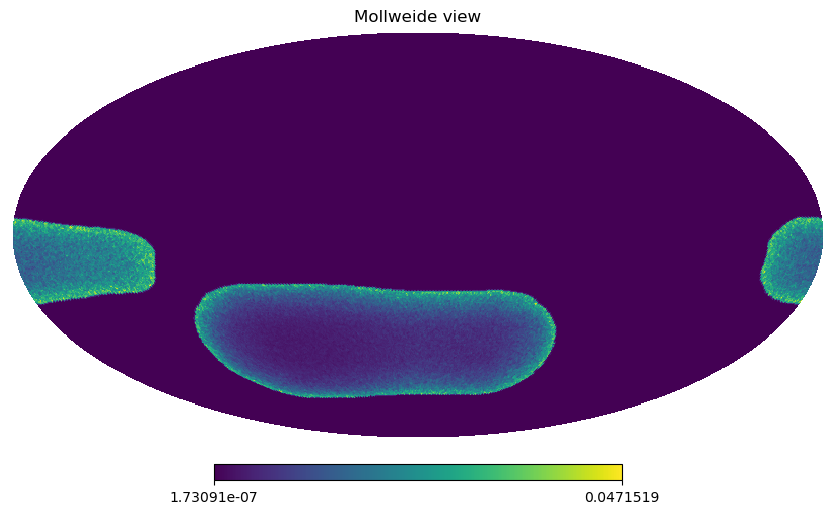

In [7]:
hp.mollview(test_noise_cov[0,1])

In [8]:
manager.get_path_to_preprocessed_maps(), os.path.exists(manager.get_path_to_preprocessed_maps())

(PosixPath('/pscratch/sd/m/mag/fast_MSS2_obsmat/validation_MEGATOP/freq_maps_preprocessed.npy'),
 True)

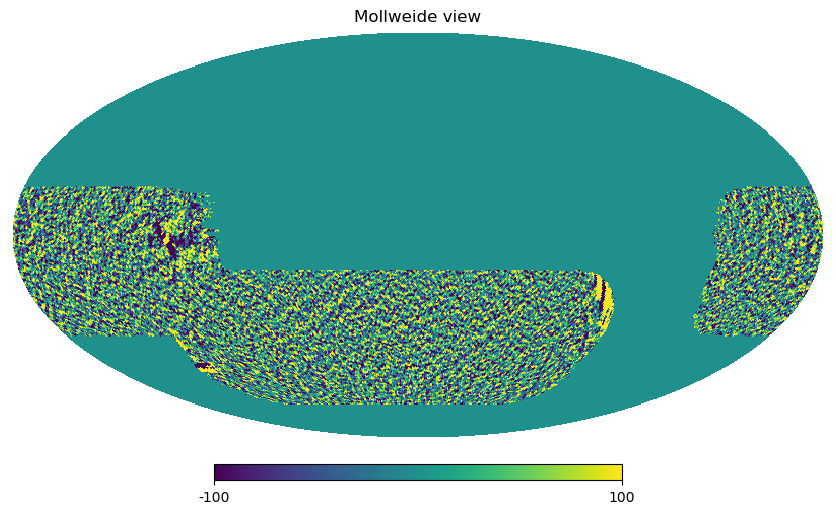

In [9]:
test_maps = np.load(manager.get_path_to_preprocessed_maps())
hp.mollview(test_maps[0,0], max=100, min=-100)

In [10]:
test_maps.shape

(6, 3, 196608)

In [11]:
manager.path_to_binary_mask, os.path.exists(manager.path_to_binary_mask)

(PosixPath('/pscratch/sd/m/mag/fast_MSS2_obsmat/validation_MEGATOP/mask_B_ring.fits'),
 True)

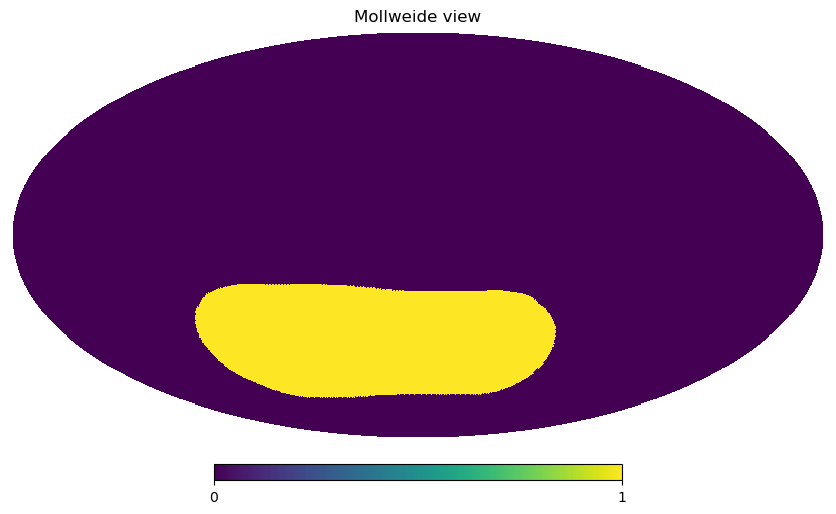

In [12]:
hp.mollview(hp.read_map(manager.path_to_binary_mask))

In [13]:
test_diag_obsmat = np.load(manager.get_path_to_diag_obsmat())
test_diag_obsmat.shape

(6, 2, 196608)

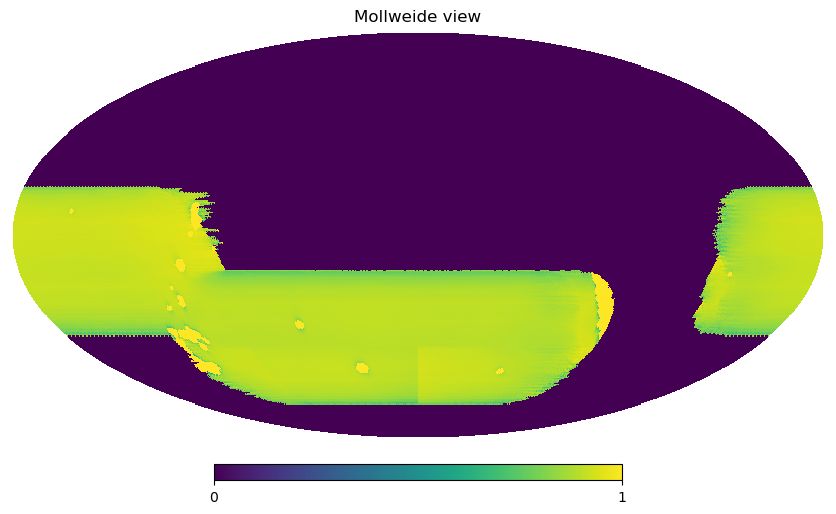

In [14]:
hp.mollview(test_diag_obsmat[0,0], nest=True)

In [15]:
manager.get_path_to_obsmat_cg()

[PosixPath('/pscratch/sd/m/mag/fast_MSS2_obsmat/sobs_RC1.r01_SAT4_mission_f030_4way_coadd_sky_obsmat_healpix__south_threshold_0.01'),
 PosixPath('/pscratch/sd/m/mag/fast_MSS2_obsmat/sobs_RC1.r01_SAT4_mission_f040_4way_coadd_sky_obsmat_healpix__south_threshold_0.01'),
 PosixPath('/pscratch/sd/m/mag/fast_MSS2_obsmat/sobs_RC1.r01_SAT1_mission_f090_4way_coadd_sky_obsmat_healpix__south_threshold_0.01'),
 PosixPath('/pscratch/sd/m/mag/fast_MSS2_obsmat/sobs_RC1.r01_SAT1_mission_f150_4way_coadd_sky_obsmat_healpix__south_threshold_0.01'),
 PosixPath('/pscratch/sd/m/mag/fast_MSS2_obsmat/sobs_RC1.r01_SAT3_mission_f230_4way_coadd_sky_obsmat_healpix__south_threshold_0.01'),
 PosixPath('/pscratch/sd/m/mag/fast_MSS2_obsmat/sobs_RC1.r01_SAT3_mission_f290_4way_coadd_sky_obsmat_healpix__south_threshold_0.01')]

In [16]:
manager.get_path_to_obsmat_rhs()

[PosixPath('/pscratch/sd/m/mag/fast_MSS2_obsmat/sobs_RC1.r01_SAT4_mission_f030_4way_coadd_sky_obsmat_healpix__south'),
 PosixPath('/pscratch/sd/m/mag/fast_MSS2_obsmat/sobs_RC1.r01_SAT4_mission_f040_4way_coadd_sky_obsmat_healpix__south'),
 PosixPath('/pscratch/sd/m/mag/fast_MSS2_obsmat/sobs_RC1.r01_SAT1_mission_f090_4way_coadd_sky_obsmat_healpix__south'),
 PosixPath('/pscratch/sd/m/mag/fast_MSS2_obsmat/sobs_RC1.r01_SAT1_mission_f150_4way_coadd_sky_obsmat_healpix__south'),
 PosixPath('/pscratch/sd/m/mag/fast_MSS2_obsmat/sobs_RC1.r01_SAT3_mission_f230_4way_coadd_sky_obsmat_healpix__south'),
 PosixPath('/pscratch/sd/m/mag/fast_MSS2_obsmat/sobs_RC1.r01_SAT3_mission_f290_4way_coadd_sky_obsmat_healpix__south')]

In [17]:
manager.get_path_to_diag_obsmat(), os.path.exists(str(manager.get_path_to_diag_obsmat()) + '.npy')

(PosixPath('/pscratch/sd/m/mag/fast_MSS2_obsmat/validation_MEGATOP/diag_obsmat.npy'),
 False)

In [18]:
config.frequencies

[27, 39, 93, 145, 225, 280]

In [19]:
config.parametric_sep_pars.get_minimize_options_as_dict()

{'disp': False, 'gtol': 1e-12, 'eps': 1e-12, 'maxiter': 20, 'ftol': 1e-12}

In [20]:
config.parametric_sep_pars.include_synchrotron

True

In [21]:
config.parametric_sep_pars.return_transpose_rhs

True

In [22]:
from megatop.pipeline.parametric_separater import megabuster_comp_sep

In [23]:
%%time
res_test = megabuster_comp_sep(
    manager,
    config
    )

13-Jul-25 12:14:57 - INFO: Elapsed time [load-covmat]: 9.201 ms
13-Jul-25 12:14:57 - INFO: Elapsed time [load-maps]: 6.088 ms
13-Jul-25 12:16:53 - INFO: Elapsed time [load-obsmat]: 1 m 55 s
13-Jul-25 12:16:53 - INFO: Elapsed time [apply-binary-mask]: 15.918 ms
13-Jul-25 12:16:53 - INFO: Elapsed time [apply-binary-mask]: 14.233 ms


Precomputing the right-hand side of the CG equation . . .
Right-hand side of the CG equation precomputed!
Using diag offdiag obsmat
Launching minimization!!
Converged in 77 iterations
Converged in 77 iterations
Converged in 77 iterations
Converged in 80 iterations
Converged in 77 iterations
Converged in 77 iterations
Converged in 77 iterations
Converged in 77 iterations
Converged in 77 iterations
Converged in 77 iterations
Converged in 79 iterations
Converged in 79 iterations
Converged in 77 iterations
Converged in 77 iterations
Converged in 77 iterations
Minimization launched!! Preparing the retrieving of the maps . . .


13-Jul-25 12:25:09 - INFO: Success: True -> Optimization finished after 5 iterations out of 20 allowed.
13-Jul-25 12:25:09 - INFO: Spectral parameters ['beta_dust', 'beta_pl'] -> [ 1.54480744 -3.01084029]
13-Jul-25 12:25:09 - INFO: Elapsed time [do-compsep]: 8 m 16 s


Converged in 77 iterations
CPU times: user 19min 11s, sys: 3min 2s, total: 22min 14s
Wall time: 10min 12s


In [24]:
res_test.x

array([ 1.54480744, -3.01084029])